In [1]:
#Introduction

In [2]:
#Part A: Cubic Spline Interpolation


In [1]:
#PART A TESTING
import numpy as np
import matplotlib.pyplot as plt


# Define known data points
Quarter = np.arange(1, 21)
gdpGrowth = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3])


def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x)  # Step sizes between data points
    # Initialize the tridiagonal matrix coefficients
    A = np.zeros(n - 2)  # Subdiagonal
    B = np.zeros(n - 2)  # Main diagonal
    C = np.zeros(n - 2)  # Superdiagonal
    D = np.zeros(n - 2)  # Right-hand side vector
    # Populate the tridiagonal matrix coefficients
    for i in range(1, n - 1):
        A[i - 1] = h[i-1]            # Subdiagonal
        B[i - 1] = 2*(h[i-1]+h[i])             # Main diagonal
        C[i - 1] = h[i]             # Superdiagonal
        D[i - 1] = 6*((y[i+1]-y[i])/h[i] - (y[i]-y[i-1])/h[i-1])            # Right-hand side vector
    return A, B, C, D


A, B, C, D = setup_tridiagonal_matrix(Quarter, gdpGrowth)

print("Subdiagonal (A):", A)
print("Main diagonal (B):", B)
print("Superdiagonal (C):", C)
print("Right-hand side (D):", D)


Subdiagonal (A): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Main diagonal (B): [4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4.]
Superdiagonal (C): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Right-hand side (D): [  22.8  -10.8   -8.4   25.8  -31.8    3.    21.   -22.2    7.2   10.2
   -3.6  -52.8  -88.8  509.4 -536.4  117.6   71.4  -18.6]


In [4]:
def thomas_algorithm(A, B, C, D):
    n = len(B)
    # Forward elimination
    for i in range(1, n):
        w = A[i-1] / B[i-1]
        B[i] = B[i] - w * C[i-1]
        D[i] = D[i] - w * D[i-1]
    # Back substitution
    x = np.zeros(n)
    x[-1] = D[-1] / B[-1]
    
    for i in range(n-2, -1, -1):
        x[i] = (D[i] - C[i] * x[i+1]) / B[i]
    return x
    

x = thomas_algorithm(A, B, C, D)
print("Solution:", x)

Solution: [   6.54772205   -3.3908882    -3.78416926   10.12756524  -10.92609171
    1.7768016     6.81888531   -8.05234285    3.19048608    2.49039852
   -2.95208014    5.71792206  -72.71960811  196.36051038 -203.3224334
   80.52922323   -1.19445953   -4.35138512]


In [ ]:

# Generate new x values for a smooth plot
x_interp = np.linspace(0, 20, 55)
y_interp = cs(x_interp)
#CHANGE THIS FOR PART 1 AND 2




y_interp = cs(x_interp)

# Plot the original data and cubic spline interpolation
plt.plot(Quarter, gdpGrowth, 'bo', label="Data points")
plt.plot(x_interp, y_interp, 'r-', label="Cubic Spline Interpolation")
plt.title("U.S GDP Growth Rate (Quarterly, 2010 - 2023)")
plt.xlabel("Quarter")
plt.ylabel("GDP Growth (%)")
plt.legend()
plt.show()

In [4]:
#Part B: Polynomial & Least Squares Comparison

In [5]:
#PART B TESTING

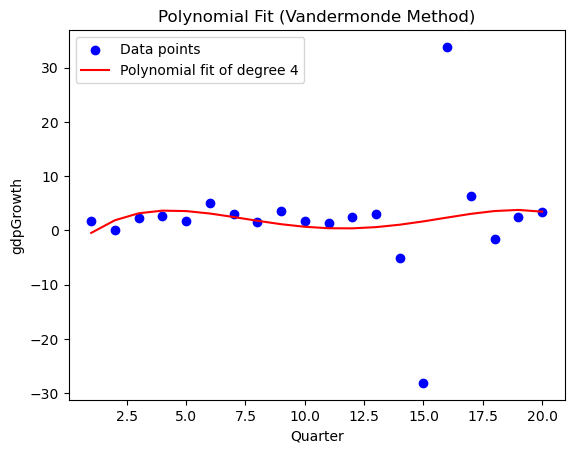

In [6]:
def create_vandermonde_matrix(x, degree):
    V = np.vander(x, N=degree+1, increasing=True)
    return V

degree = 4 # Degree of the polynomial

V = create_vandermonde_matrix(Quarter, degree)

# V.T * V
VT_V = np.dot(V.T, V)
# V.T * y
VT_y = np.dot(V.T, gdpGrowth)
# Solve for a (coefficients)
coefficients = np.linalg.solve(VT_V, VT_y)

#print("Polynomial Coefficients: ", coefficients)


polynomial = np.poly1d(coefficients[::-1])


# Generate predicted y-values based on the fitted polynomial
y_pred = polynomial(Quarter)
# Step 4: Plotting the results
plt.scatter(Quarter, gdpGrowth, color='blue', label='Data points') # Original data points
plt.plot(Quarter, y_pred, color='red', label=f'Polynomial fit of degree {degree}')
# Fitted curve
plt.title('Polynomial Fit (Vandermonde Method)')
plt.xlabel('Quarter')
plt.ylabel('gdpGrowth')
plt.legend()
plt.show()

Slope: 0.00014705882352951386, Intercept: 2.1424999999999996


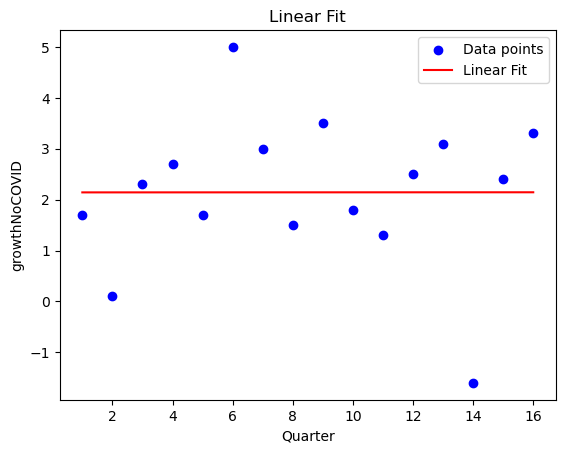

In [7]:
# Stack the design matrix with a column of ones (for the intercept)

Quarter = np.arange(1, 17)
growthNoCOVID = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 1.3, 2.5, 3.1, -1.6, 2.4, 3.3])

A = np.vstack([Quarter, np.ones(len(Quarter))]).T
# Solve using least squares
m, c = np.linalg.lstsq(A, growthNoCOVID, rcond=None)[0]
print(f"Slope: {m}, Intercept: {c}")

plt.scatter(Quarter, growthNoCOVID, color='blue', label='Data points') # Original data points
plt.plot(Quarter, (m*Quarter + c), color='red', label='Linear Fit')
plt.title('Linear Fit')
plt.xlabel('Quarter')
plt.ylabel('growthNoCOVID')
plt.legend()
plt.show()

In [8]:
#Part C: Method Justification

In [9]:
#PART C TESTING

In [10]:
# Mean Squared Error (MSE)
mse = np.mean((gdpGrowth - y_pred)**2)
print(f'Mean Squared Error: {mse:.4f}')
# R-squared value
ss_total = np.sum((gdpGrowth - np.mean(gdpGrowth))**2)
ss_res = np.sum((gdpGrowth - y_pred)**2)
r_squared = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squared:.4f}')

Mean Squared Error: 99.3077
R-squared: 0.0166


In [11]:
#Part C Addendum: Big O Analysis

In [12]:
#PART C ADDENDUM TESTING

In [13]:
#Conclusion